## Topology_A duration


=== Final Results ===
b1: F1-Score = 0.1202, Std = 0.0145
b2: F1-Score = 0.1418, Std = 0.0052
b3: F1-Score = 0.1503, Std = 0.0048
b4: F1-Score = 0.1577, Std = 0.0035
b5: F1-Score = 0.1838, Std = 0.0143
b6: F1-Score = 0.2570, Std = 0.0197
b7: F1-Score = 0.4143, Std = 0.0597
b8: F1-Score = 0.5431, Std = 0.0583
b9: F1-Score = 0.5741, Std = 0.0483
b10: F1-Score = 0.5956, Std = 0.0471
b11: F1-Score = 0.6155, Std = 0.0535
b12: F1-Score = 0.6286, Std = 0.0578
b13: F1-Score = 0.6397, Std = 0.0517
b14: F1-Score = 0.6419, Std = 0.0511
b15: F1-Score = 0.6469, Std = 0.0453
b16: F1-Score = 0.6482, Std = 0.0439
b17: F1-Score = 0.6513, Std = 0.0437
b18: F1-Score = 0.6561, Std = 0.0432
b19: F1-Score = 0.6568, Std = 0.0438
b20: F1-Score = 0.6585, Std = 0.0445
b21: F1-Score = 0.6599, Std = 0.0441
b22: F1-Score = 0.6599, Std = 0.0441
b23: F1-Score = 0.6599, Std = 0.0441
b24: F1-Score = 0.6599, Std = 0.0441
b25: F1-Score = 0.6599, Std = 0.0441
b26: F1-Score = 0.6599, Std = 0.0441
b27: F1-Score = 0.6599, 

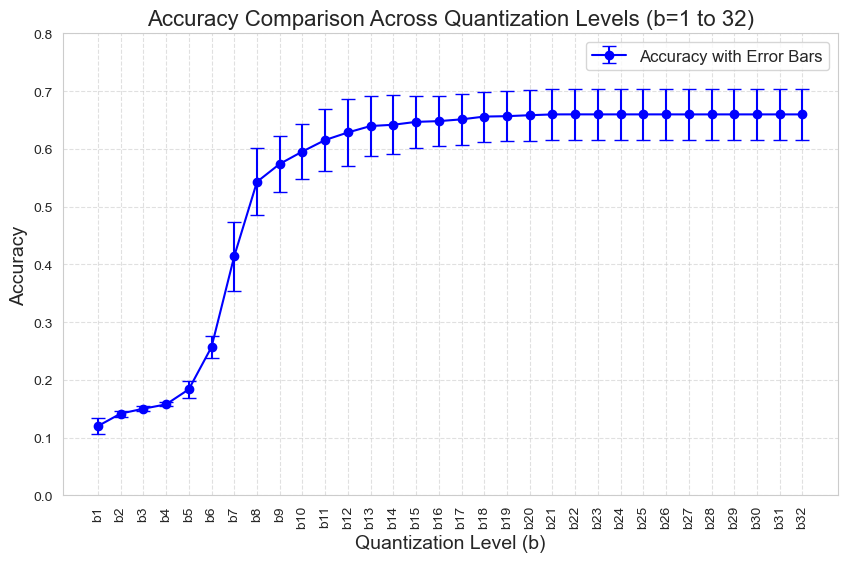

In [8]:
# classification
import pandas as pd
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

def quantize(data, b):
    min_val = data.min()
    max_val = data.max()

    levels = 2 ** b
    step = (max_val - min_val) / levels

    quantized_indexes = np.floor((data - min_val) / step)
    quantized_indexes = np.clip(quantized_indexes, 0, levels - 1)

    quantized_data = quantized_indexes * step + min_val
    return quantized_data, quantized_indexes

base_dir = "D:/ZBIOT-2025/Dataset"
input_folder = os.path.join(base_dir, "Merged_Data", "A_6-Merged_sequence_data_fix_durations")
output_folder = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_durations", "Quantized_values")
output_folder2 = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_durations", "Quantized_index")
os.makedirs(output_folder, exist_ok=True)
os.makedirs(output_folder2, exist_ok=True)

b_values = list(range(1, 33))  # b be from 1 to 32.

file_name = "Topology_A_fix_duration.csv"
input_file_path = os.path.join(input_folder, file_name)
df = pd.read_csv(input_file_path)
columns_to_quantize = df.columns[3:10]

for b in b_values:
    try:
        quantized_df = df.copy()
        index_df = df.copy()
        for col in columns_to_quantize:
            quantized_values, quantized_indexes = quantize(df[col].values, b)
            quantized_df[col] = quantized_values
            index_df[col] = quantized_indexes

        new_file_name = file_name.replace(".csv", "")
        output_file = os.path.join(output_folder, f"{new_file_name}_value_b{b}.csv")
        output_index_file = os.path.join(output_folder2, f"{new_file_name}_index_b{b}.csv")

        quantized_df.to_csv(output_file, index=False)
        index_df.to_csv(output_index_file, index=False)
    except MemoryError:
        print(f"Quantization failed for b={b}")

file_paths = {f"b{b}": os.path.join(output_folder, f"{new_file_name}_value_b{b}.csv") for b in b_values}
file_paths["Original"] = os.path.join(input_folder, file_name)

folds = 5
accuracies_per_file = {file_name: [] for file_name in file_paths.keys() if file_name != "Original"}

original_data = pd.read_csv(file_paths["Original"])
X_original = original_data.drop(columns=["Device Name", "Device Type", "File Name"])
y_original = original_data["Device Type"]
y_original = y_original.astype("category")
categories = y_original.cat.categories
y_original = y_original.cat.codes

skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)

for train_indices, test_indices in skf.split(X_original, y_original):
    X_train, X_test = X_original.iloc[train_indices], X_original.iloc[test_indices]
    y_train, y_test_original = y_original[train_indices], y_original[test_indices]

    class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

    rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
    rf_model.fit(X_train, y_train)

    for file_name, file_path in file_paths.items():
        if file_name == "Original":
            continue

        quantized_data = pd.read_csv(file_path)
        X_test_quantized = quantized_data.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[test_indices]
        y_test_quantized = quantized_data["Device Type"].iloc[test_indices]
        y_test_quantized = y_test_quantized.astype("category")
        y_test_quantized = y_test_quantized.cat.set_categories(categories).cat.codes

        y_pred = rf_model.predict(X_test_quantized)
        F1_sc = f1_score(y_test_quantized, y_pred, average='macro')
        accuracies_per_file[file_name].append(F1_sc)

mean_accuracies = {file_name: np.mean(accs) for file_name, accs in accuracies_per_file.items()}
std_accuracies = {file_name: np.std(accs) for file_name, accs in accuracies_per_file.items()}

print("\n=== Final Results ===")
for file_name, mean_acc in sorted(mean_accuracies.items(), key=lambda x: int(x[0][1:])):
    print(f"{file_name}: F1-Score = {mean_acc:.4f}, Std = {std_accuracies[file_name]:.4f}")

plt.figure(figsize=(10, 6))
b_values_sorted = sorted(mean_accuracies.keys(), key=lambda x: int(x[1:]))
plt.errorbar(
    b_values_sorted,
    [mean_accuracies[b] for b in b_values_sorted],
    yerr=[std_accuracies[b] for b in b_values_sorted],
    fmt="o-", capsize=5, label="Accuracy with Error Bars", color="blue",
)
plt.title("Accuracy Comparison Across Quantization Levels (b=1 to 32)", fontsize=16)
plt.xlabel("Quantization Level (b)", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.ylim(0, 0.8)
plt.xticks(rotation=90)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12)
plt.show()



=== Final Results ===
b1: F1-Score = 0.0230, Std = 0.0045
b2: F1-Score = 0.0259, Std = 0.0019
b3: F1-Score = 0.0638, Std = 0.0069
b4: F1-Score = 0.0992, Std = 0.0107
b5: F1-Score = 0.1561, Std = 0.0116
b6: F1-Score = 0.2079, Std = 0.0054
b7: F1-Score = 0.3468, Std = 0.0277
b8: F1-Score = 0.3976, Std = 0.0371
b9: F1-Score = 0.4108, Std = 0.0398
b10: F1-Score = 0.4390, Std = 0.0249
b11: F1-Score = 0.4555, Std = 0.0228
b12: F1-Score = 0.4629, Std = 0.0272
b13: F1-Score = 0.4680, Std = 0.0277
b14: F1-Score = 0.4704, Std = 0.0269
b15: F1-Score = 0.4683, Std = 0.0276
b16: F1-Score = 0.4698, Std = 0.0273
b17: F1-Score = 0.4700, Std = 0.0242
b18: F1-Score = 0.4730, Std = 0.0251
b19: F1-Score = 0.4746, Std = 0.0246
b20: F1-Score = 0.4746, Std = 0.0245
b21: F1-Score = 0.4748, Std = 0.0241
b22: F1-Score = 0.4747, Std = 0.0243
b23: F1-Score = 0.4746, Std = 0.0244
b24: F1-Score = 0.4747, Std = 0.0243
b25: F1-Score = 0.4747, Std = 0.0243
b26: F1-Score = 0.4748, Std = 0.0243
b27: F1-Score = 0.4748, 

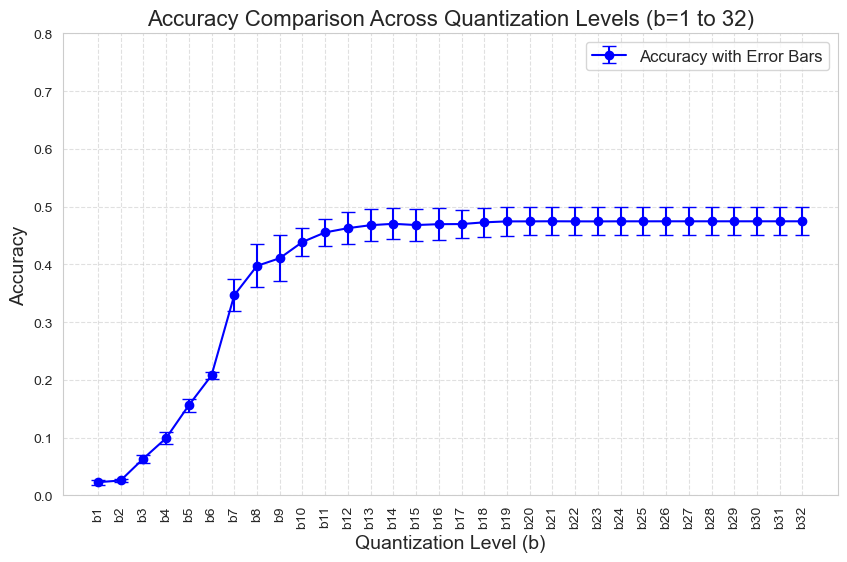

In [16]:
# identification
import pandas as pd
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

def quantize(data, b):
    min_val = data.min()
    max_val = data.max()

    levels = 2 ** b
    step = (max_val - min_val) / levels

    quantized_indexes = np.floor((data - min_val) / step)
    quantized_indexes = np.clip(quantized_indexes, 0, levels - 1)

    quantized_data = quantized_indexes * step + min_val
    return quantized_data, quantized_indexes

base_dir = "D:/ZBIOT-2025/Dataset"
input_folder = os.path.join(base_dir, "Merged_Data", "A_6-Merged_sequence_data_fix_durations")
output_folder = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_durations", "Quantized_values")
output_folder2 = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_durations", "Quantized_index")
os.makedirs(output_folder, exist_ok=True)
os.makedirs(output_folder2, exist_ok=True)

b_values = list(range(1, 33))  # b be from 1 to 32.

file_name = "Topology_A_fix_duration.csv"
input_file_path = os.path.join(input_folder, file_name)
df = pd.read_csv(input_file_path)
columns_to_quantize = df.columns[3:10]

for b in b_values:
    try:
        quantized_df = df.copy()
        index_df = df.copy()
        for col in columns_to_quantize:
            quantized_values, quantized_indexes = quantize(df[col].values, b)
            quantized_df[col] = quantized_values
            index_df[col] = quantized_indexes

        new_file_name = file_name.replace(".csv", "")
        output_file = os.path.join(output_folder, f"{new_file_name}_value_b{b}.csv")
        output_index_file = os.path.join(output_folder2, f"{new_file_name}_index_b{b}.csv")

        quantized_df.to_csv(output_file, index=False)
        index_df.to_csv(output_index_file, index=False)
    except MemoryError:
        print(f"Quantization failed for b={b}")

file_paths = {f"b{b}": os.path.join(output_folder, f"{new_file_name}_value_b{b}.csv") for b in b_values}
file_paths["Original"] = os.path.join(input_folder, file_name)

folds = 5
accuracies_per_file = {file_name: [] for file_name in file_paths.keys() if file_name != "Original"}

original_data = pd.read_csv(file_paths["Original"])
X_original = original_data.drop(columns=["Device Name", "Device Type", "File Name"])
y_original = original_data["Device Name"]
y_original = y_original.astype("category")
categories = y_original.cat.categories
y_original = y_original.cat.codes

skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)

for train_indices, test_indices in skf.split(X_original, y_original):
    X_train, X_test = X_original.iloc[train_indices], X_original.iloc[test_indices]
    y_train, y_test_original = y_original[train_indices], y_original[test_indices]

    class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

    rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
    rf_model.fit(X_train, y_train)

    for file_name, file_path in file_paths.items():
        if file_name == "Original":
            continue

        quantized_data = pd.read_csv(file_path)
        X_test_quantized = quantized_data.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[test_indices]
        y_test_quantized = quantized_data["Device Name"].iloc[test_indices]
        y_test_quantized = y_test_quantized.astype("category")
        y_test_quantized = y_test_quantized.cat.set_categories(categories).cat.codes

        y_pred = rf_model.predict(X_test_quantized)
        F1_sc = f1_score(y_test_quantized, y_pred, average='macro')
        accuracies_per_file[file_name].append(F1_sc)

mean_accuracies = {file_name: np.mean(accs) for file_name, accs in accuracies_per_file.items()}
std_accuracies = {file_name: np.std(accs) for file_name, accs in accuracies_per_file.items()}

print("\n=== Final Results ===")
for file_name, mean_acc in sorted(mean_accuracies.items(), key=lambda x: int(x[0][1:])):
    print(f"{file_name}: F1-Score = {mean_acc:.4f}, Std = {std_accuracies[file_name]:.4f}")

plt.figure(figsize=(10, 6))
b_values_sorted = sorted(mean_accuracies.keys(), key=lambda x: int(x[1:]))
plt.errorbar(
    b_values_sorted,
    [mean_accuracies[b] for b in b_values_sorted],
    yerr=[std_accuracies[b] for b in b_values_sorted],
    fmt="o-", capsize=5, label="Accuracy with Error Bars", color="blue",
)
plt.title("Accuracy Comparison Across Quantization Levels (b=1 to 32)", fontsize=16)
plt.xlabel("Quantization Level (b)", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.ylim(0, 0.8)
plt.xticks(rotation=90)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12)
plt.show()



=== Final Results for Each Training Set ===

--- Train on Original ---
Test b1: F1-Score = 0.1202, Std = 0.0145
Test b2: F1-Score = 0.1418, Std = 0.0052
Test b3: F1-Score = 0.1503, Std = 0.0048
Test b4: F1-Score = 0.1577, Std = 0.0035
Test b5: F1-Score = 0.1838, Std = 0.0143
Test b6: F1-Score = 0.2570, Std = 0.0197
Test b7: F1-Score = 0.4143, Std = 0.0597
Test b8: F1-Score = 0.5431, Std = 0.0583
Test b9: F1-Score = 0.5741, Std = 0.0483
Test b10: F1-Score = 0.5956, Std = 0.0471
Test b11: F1-Score = 0.6155, Std = 0.0535
Test b12: F1-Score = 0.6286, Std = 0.0578
Test b13: F1-Score = 0.6397, Std = 0.0517
Test b14: F1-Score = 0.6419, Std = 0.0511
Test b15: F1-Score = 0.6469, Std = 0.0453
Test b16: F1-Score = 0.6482, Std = 0.0439
Test b17: F1-Score = 0.6513, Std = 0.0437
Test b18: F1-Score = 0.6561, Std = 0.0432
Test b19: F1-Score = 0.6568, Std = 0.0438
Test b20: F1-Score = 0.6585, Std = 0.0445
Test b21: F1-Score = 0.6599, Std = 0.0441
Test b22: F1-Score = 0.6599, Std = 0.0441
Test b23: F1-

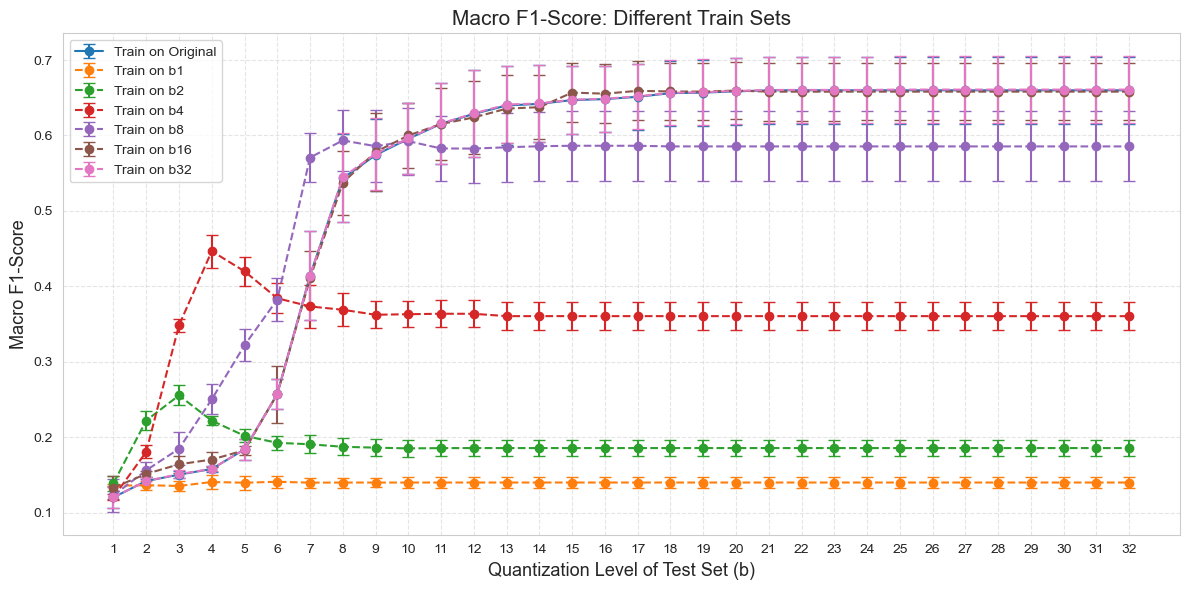

In [18]:
import pandas as pd
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

# 设置路径
base_dir = "D:/ZBIOT-2025/Dataset"
input_folder = os.path.join(base_dir, "Merged_Data", "A_6-Merged_sequence_data_fix_durations")
quantized_folder = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_durations", "Quantized_values")

file_name = "Topology_A_fix_duration.csv"
input_file_path = os.path.join(input_folder, file_name)

df_original = pd.read_csv(input_file_path)
X_original = df_original.drop(columns=["Device Name", "Device Type", "File Name"])
y_original = df_original["Device Type"].astype("category")
categories = y_original.cat.categories
y_original = y_original.cat.codes

b_values = list(range(1, 33))
quantized_paths = {f"b{b}": os.path.join(quantized_folder, f"Topology_A_fix_duration_value_b{b}.csv") for b in b_values}

train_sources = {"Original": input_file_path}
for b in [1, 2, 4, 8, 16, 32]:
    train_sources[f"b{b}"] = quantized_paths[f"b{b}"]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_matrix = {train_name: {f"b{b}": [] for b in b_values} for train_name in train_sources}

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X_original, y_original)):
    for train_name, train_path in train_sources.items():
        df_train = pd.read_csv(train_path)
        X_train = df_train.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[train_idx]
        y_train = df_train["Device Type"].astype("category")
        y_train = y_train.cat.set_categories(categories).cat.codes.iloc[train_idx]

        class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
        rf_model = RandomForestClassifier(random_state=42, class_weight={i: w for i, w in enumerate(class_weights)})
        rf_model.fit(X_train, y_train)

        for b in b_values:
            test_path = quantized_paths[f"b{b}"]
            df_test = pd.read_csv(test_path)
            X_test = df_test.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[test_idx]
            y_test = df_test["Device Type"].astype("category").cat.set_categories(categories).cat.codes.iloc[test_idx]

            y_pred = rf_model.predict(X_test)
            f1 = f1_score(y_test, y_pred, average='macro')
            f1_matrix[train_name][f"b{b}"].append(f1)

mean_f1_matrix = {train_name: [np.mean(f1_matrix[train_name][f"b{b}"]) for b in b_values] for train_name in f1_matrix}
std_f1_matrix = {train_name: [np.std(f1_matrix[train_name][f"b{b}"]) for b in b_values] for train_name in f1_matrix}

plt.figure(figsize=(12, 6))
for train_name in f1_matrix:
    plt.errorbar(
        b_values,
        mean_f1_matrix[train_name],
        yerr=std_f1_matrix[train_name],
        label=f"Train on {train_name}",
        capsize=4,
        marker='o',
        linestyle='--' if train_name != "Original" else '-'
    )
print("\n=== Final Results for Each Training Set ===")
for train_name in mean_f1_matrix:
    print(f"\n--- Train on {train_name} ---")
    for b, mean_acc in zip(b_values, mean_f1_matrix[train_name]):
        std = std_f1_matrix[train_name][b - 1]
        print(f"Test b{b}: F1-Score = {mean_acc:.4f}, Std = {std:.4f}")

plt.title("Macro F1-Score: Different Train Sets", fontsize=15)
plt.xlabel("Quantization Level of Test Set (b)", fontsize=13)
plt.ylabel("Macro F1-Score", fontsize=13)
plt.xticks(b_values)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()



=== Final Results for Each Training Set ===

--- Train on Original ---
Test b1: F1-Score = 0.0230, Std = 0.0045
Test b2: F1-Score = 0.0259, Std = 0.0019
Test b3: F1-Score = 0.0638, Std = 0.0069
Test b4: F1-Score = 0.0992, Std = 0.0107
Test b5: F1-Score = 0.1561, Std = 0.0116
Test b6: F1-Score = 0.2079, Std = 0.0054
Test b7: F1-Score = 0.3468, Std = 0.0277
Test b8: F1-Score = 0.3976, Std = 0.0371
Test b9: F1-Score = 0.4108, Std = 0.0398
Test b10: F1-Score = 0.4390, Std = 0.0249
Test b11: F1-Score = 0.4555, Std = 0.0228
Test b12: F1-Score = 0.4629, Std = 0.0272
Test b13: F1-Score = 0.4680, Std = 0.0277
Test b14: F1-Score = 0.4704, Std = 0.0269
Test b15: F1-Score = 0.4683, Std = 0.0276
Test b16: F1-Score = 0.4698, Std = 0.0273
Test b17: F1-Score = 0.4700, Std = 0.0242
Test b18: F1-Score = 0.4730, Std = 0.0251
Test b19: F1-Score = 0.4746, Std = 0.0246
Test b20: F1-Score = 0.4746, Std = 0.0245
Test b21: F1-Score = 0.4748, Std = 0.0241
Test b22: F1-Score = 0.4747, Std = 0.0243
Test b23: F1-

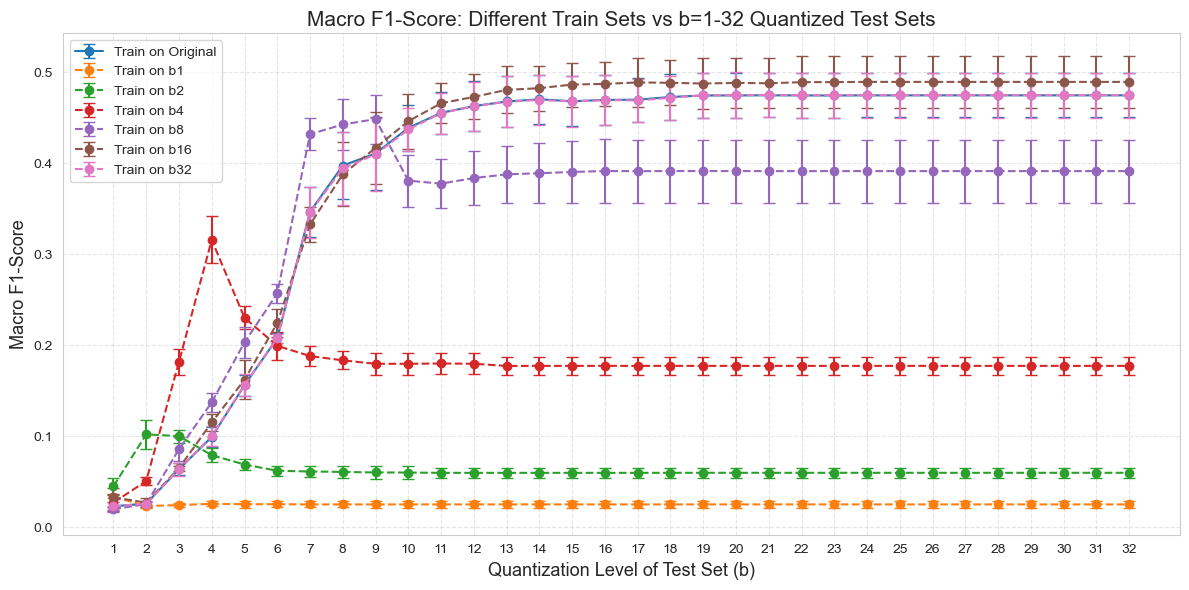

In [17]:
import pandas as pd
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

# 设置路径
base_dir = "D:/ZBIOT-2025/Dataset"
input_folder = os.path.join(base_dir, "Merged_Data", "A_6-Merged_sequence_data_fix_durations")
quantized_folder = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_durations", "Quantized_values")

file_name = "Topology_A_fix_duration.csv"
input_file_path = os.path.join(input_folder, file_name)

df_original = pd.read_csv(input_file_path)
X_original = df_original.drop(columns=["Device Name", "Device Type", "File Name"])
y_original = df_original["Device Name"].astype("category")
categories = y_original.cat.categories
y_original = y_original.cat.codes

b_values = list(range(1, 33))
quantized_paths = {f"b{b}": os.path.join(quantized_folder, f"Topology_A_fix_duration_value_b{b}.csv") for b in b_values}

train_sources = {"Original": input_file_path}
for b in [1, 2, 4, 8, 16, 32]:
    train_sources[f"b{b}"] = quantized_paths[f"b{b}"]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_matrix = {train_name: {f"b{b}": [] for b in b_values} for train_name in train_sources}

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X_original, y_original)):
    for train_name, train_path in train_sources.items():
        df_train = pd.read_csv(train_path)
        X_train = df_train.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[train_idx]
        y_train = df_train["Device Name"].astype("category")
        y_train = y_train.cat.set_categories(categories).cat.codes.iloc[train_idx]

        class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
        rf_model = RandomForestClassifier(random_state=42, class_weight={i: w for i, w in enumerate(class_weights)})
        rf_model.fit(X_train, y_train)

        for b in b_values:
            test_path = quantized_paths[f"b{b}"]
            df_test = pd.read_csv(test_path)
            X_test = df_test.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[test_idx]
            y_test = df_test["Device Name"].astype("category").cat.set_categories(categories).cat.codes.iloc[test_idx]

            y_pred = rf_model.predict(X_test)
            f1 = f1_score(y_test, y_pred, average='macro')
            f1_matrix[train_name][f"b{b}"].append(f1)

mean_f1_matrix = {train_name: [np.mean(f1_matrix[train_name][f"b{b}"]) for b in b_values] for train_name in f1_matrix}
std_f1_matrix = {train_name: [np.std(f1_matrix[train_name][f"b{b}"]) for b in b_values] for train_name in f1_matrix}

plt.figure(figsize=(12, 6))
for train_name in f1_matrix:
    plt.errorbar(
        b_values,
        mean_f1_matrix[train_name],
        yerr=std_f1_matrix[train_name],
        label=f"Train on {train_name}",
        capsize=4,
        marker='o',
        linestyle='--' if train_name != "Original" else '-'
    )
print("\n=== Final Results for Each Training Set ===")
for train_name in mean_f1_matrix:
    print(f"\n--- Train on {train_name} ---")
    for b, mean_acc in zip(b_values, mean_f1_matrix[train_name]):
        std = std_f1_matrix[train_name][b - 1]
        print(f"Test b{b}: F1-Score = {mean_acc:.4f}, Std = {std:.4f}")

plt.title("Macro F1-Score: Different Train Sets vs b=1-32 Quantized Test Sets", fontsize=15)
plt.xlabel("Quantization Level of Test Set (b)", fontsize=13)
plt.ylabel("Macro F1-Score", fontsize=13)
plt.xticks(b_values)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()



=== Final Results ===

--- Original ---
Test b1: F1-Score = 0.0230, Std = 0.0045
Test b2: F1-Score = 0.0259, Std = 0.0019
Test b3: F1-Score = 0.0638, Std = 0.0069
Test b4: F1-Score = 0.0992, Std = 0.0107
Test b5: F1-Score = 0.1561, Std = 0.0116
Test b6: F1-Score = 0.2079, Std = 0.0054
Test b7: F1-Score = 0.3468, Std = 0.0277
Test b8: F1-Score = 0.3976, Std = 0.0371
Test b9: F1-Score = 0.4108, Std = 0.0398
Test b10: F1-Score = 0.4390, Std = 0.0249
Test b11: F1-Score = 0.4555, Std = 0.0228
Test b12: F1-Score = 0.4629, Std = 0.0272
Test b13: F1-Score = 0.4680, Std = 0.0277
Test b14: F1-Score = 0.4704, Std = 0.0269
Test b15: F1-Score = 0.4683, Std = 0.0276
Test b16: F1-Score = 0.4698, Std = 0.0273
Test b17: F1-Score = 0.4700, Std = 0.0242
Test b18: F1-Score = 0.4730, Std = 0.0251
Test b19: F1-Score = 0.4746, Std = 0.0246
Test b20: F1-Score = 0.4746, Std = 0.0245
Test b21: F1-Score = 0.4748, Std = 0.0241
Test b22: F1-Score = 0.4747, Std = 0.0243
Test b23: F1-Score = 0.4746, Std = 0.0244
Te

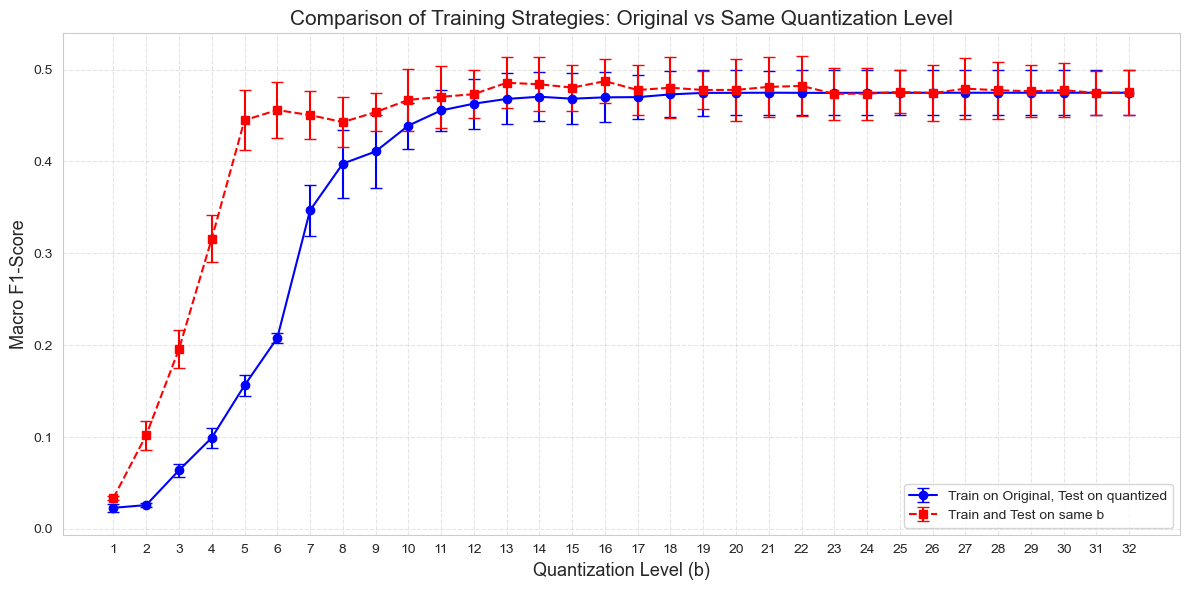

In [23]:
import pandas as pd
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

base_dir = "D:/ZBIOT-2025/Dataset"
input_folder = os.path.join(base_dir, "Merged_Data", "A_6-Merged_sequence_data_fix_durations")
quantized_folder = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_durations", "Quantized_values")

file_name = "Topology_A_fix_duration.csv"
input_file_path = os.path.join(input_folder, file_name)

df_original = pd.read_csv(input_file_path)
X_original = df_original.drop(columns=["Device Name", "Device Type", "File Name"])
y_original = df_original["Device Name"].astype("category")
categories = y_original.cat.categories
y_original = y_original.cat.codes

b_values = list(range(1, 33))
quantized_paths = {f"b{b}": os.path.join(quantized_folder, f"Topology_A_fix_duration_value_b{b}.csv") for b in b_values}

train_sources = {
    "Original": input_file_path,
    "Same b": None
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_matrix = {train_name: {f"b{b}": [] for b in b_values} for train_name in train_sources}

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X_original, y_original)):
    df_train = pd.read_csv(train_sources["Original"])
    X_train = df_train.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[train_idx]
    y_train = df_train["Device Name"].astype("category")
    y_train = y_train.cat.set_categories(categories).cat.codes.iloc[train_idx]

    class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
    rf_model = RandomForestClassifier(random_state=42, class_weight={i: w for i, w in enumerate(class_weights)})
    rf_model.fit(X_train, y_train)

    for b in b_values:
        test_path = quantized_paths[f"b{b}"]
        df_test = pd.read_csv(test_path)
        X_test = df_test.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[test_idx]
        y_test = df_test["Device Name"].astype("category").cat.set_categories(categories).cat.codes.iloc[test_idx]

        y_pred = rf_model.predict(X_test)
        f1 = f1_score(y_test, y_pred, average='macro')
        f1_matrix["Original"][f"b{b}"].append(f1)

    for b in b_values:
        train_path = quantized_paths[f"b{b}"]
        df_train = pd.read_csv(train_path)
        X_train = df_train.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[train_idx]
        y_train = df_train["Device Name"].astype("category")
        y_train = y_train.cat.set_categories(categories).cat.codes.iloc[train_idx]

        class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
        rf_model = RandomForestClassifier(random_state=42, class_weight={i: w for i, w in enumerate(class_weights)})
        rf_model.fit(X_train, y_train)

        test_path = quantized_paths[f"b{b}"]
        df_test = pd.read_csv(test_path)
        X_test = df_test.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[test_idx]
        y_test = df_test["Device Name"].astype("category").cat.set_categories(categories).cat.codes.iloc[test_idx]

        y_pred = rf_model.predict(X_test)
        f1 = f1_score(y_test, y_pred, average='macro')
        f1_matrix["Same b"][f"b{b}"].append(f1)

mean_f1_matrix = {train_name: [np.mean(f1_matrix[train_name][f"b{b}"]) for b in b_values] for train_name in f1_matrix}
std_f1_matrix = {train_name: [np.std(f1_matrix[train_name][f"b{b}"]) for b in b_values] for train_name in f1_matrix}

plt.figure(figsize=(12, 6))

plt.errorbar(
    b_values,
    mean_f1_matrix["Original"],
    yerr=std_f1_matrix["Original"],
    label="Train on Original, Test on quantized",
    capsize=4,
    marker='o',
    linestyle='-',
    color='blue'
)

plt.errorbar(
    b_values,
    mean_f1_matrix["Same b"],
    yerr=std_f1_matrix["Same b"],
    label="Train and Test on same b",
    capsize=4,
    marker='s',
    linestyle='--',
    color='red'
)

print("\n=== Final Results ===")
for train_name in mean_f1_matrix:
    print(f"\n--- {train_name} ---")
    for b, mean_acc in zip(b_values, mean_f1_matrix[train_name]):
        std = std_f1_matrix[train_name][b - 1]
        print(f"Test b{b}: F1-Score = {mean_acc:.4f}, Std = {std:.4f}")

plt.title("Comparison of Training Strategies: Original vs Same Quantization Level", fontsize=15)
plt.xlabel("Quantization Level (b)", fontsize=13)
plt.ylabel("Macro F1-Score", fontsize=13)
plt.xticks(b_values)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


=== Final Results ===

--- Original ---
Test b1: F1-Score = 0.1202, Std = 0.0145
Test b2: F1-Score = 0.1418, Std = 0.0052
Test b3: F1-Score = 0.1503, Std = 0.0048
Test b4: F1-Score = 0.1577, Std = 0.0035
Test b5: F1-Score = 0.1838, Std = 0.0143
Test b6: F1-Score = 0.2570, Std = 0.0197
Test b7: F1-Score = 0.4143, Std = 0.0597
Test b8: F1-Score = 0.5431, Std = 0.0583
Test b9: F1-Score = 0.5741, Std = 0.0483
Test b10: F1-Score = 0.5956, Std = 0.0471
Test b11: F1-Score = 0.6155, Std = 0.0535
Test b12: F1-Score = 0.6286, Std = 0.0578
Test b13: F1-Score = 0.6397, Std = 0.0517
Test b14: F1-Score = 0.6419, Std = 0.0511
Test b15: F1-Score = 0.6469, Std = 0.0453
Test b16: F1-Score = 0.6482, Std = 0.0439
Test b17: F1-Score = 0.6513, Std = 0.0437
Test b18: F1-Score = 0.6561, Std = 0.0432
Test b19: F1-Score = 0.6568, Std = 0.0438
Test b20: F1-Score = 0.6585, Std = 0.0445
Test b21: F1-Score = 0.6599, Std = 0.0441
Test b22: F1-Score = 0.6599, Std = 0.0441
Test b23: F1-Score = 0.6599, Std = 0.0441
Te

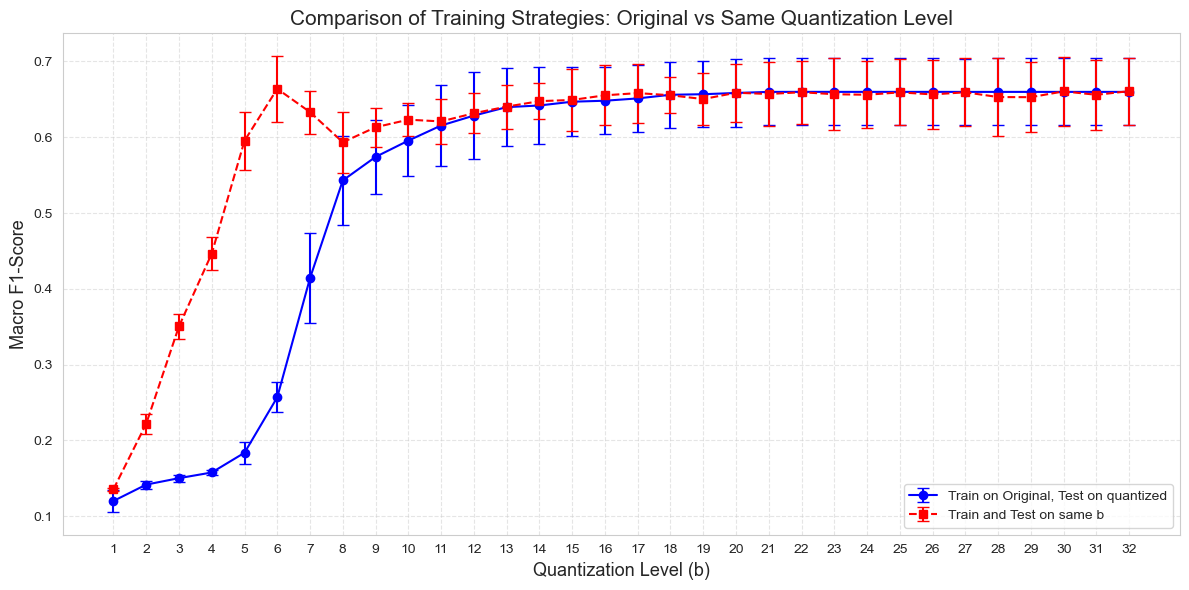

In [24]:
import pandas as pd
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

# 设置路径
base_dir = "D:/ZBIOT-2025/Dataset"
input_folder = os.path.join(base_dir, "Merged_Data", "A_6-Merged_sequence_data_fix_durations")
quantized_folder = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_durations", "Quantized_values")

file_name = "Topology_A_fix_duration.csv"
input_file_path = os.path.join(input_folder, file_name)

df_original = pd.read_csv(input_file_path)
X_original = df_original.drop(columns=["Device Name", "Device Type", "File Name"])
y_original = df_original["Device Type"].astype("category")
categories = y_original.cat.categories
y_original = y_original.cat.codes

b_values = list(range(1, 33))
quantized_paths = {f"b{b}": os.path.join(quantized_folder, f"Topology_A_fix_duration_value_b{b}.csv") for b in b_values}

# 我们只需要保留Original和Same b两种情况
train_sources = {
    "Original": input_file_path,
    "Same b": None  # 特殊标记，表示训练和测试使用相同的b值
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_matrix = {train_name: {f"b{b}": [] for b in b_values} for train_name in train_sources}

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X_original, y_original)):
    # 处理Original情况
    df_train = pd.read_csv(train_sources["Original"])
    X_train = df_train.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[train_idx]
    y_train = df_train["Device Type"].astype("category")
    y_train = y_train.cat.set_categories(categories).cat.codes.iloc[train_idx]

    class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
    rf_model = RandomForestClassifier(random_state=42, class_weight={i: w for i, w in enumerate(class_weights)})
    rf_model.fit(X_train, y_train)

    for b in b_values:
        test_path = quantized_paths[f"b{b}"]
        df_test = pd.read_csv(test_path)
        X_test = df_test.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[test_idx]
        y_test = df_test["Device Type"].astype("category").cat.set_categories(categories).cat.codes.iloc[test_idx]

        y_pred = rf_model.predict(X_test)
        f1 = f1_score(y_test, y_pred, average='macro')
        f1_matrix["Original"][f"b{b}"].append(f1)

    # 处理Same b情况 - 训练和测试使用相同的b值
    for b in b_values:
        train_path = quantized_paths[f"b{b}"]
        df_train = pd.read_csv(train_path)
        X_train = df_train.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[train_idx]
        y_train = df_train["Device Type"].astype("category")
        y_train = y_train.cat.set_categories(categories).cat.codes.iloc[train_idx]

        class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
        rf_model = RandomForestClassifier(random_state=42, class_weight={i: w for i, w in enumerate(class_weights)})
        rf_model.fit(X_train, y_train)

        test_path = quantized_paths[f"b{b}"]
        df_test = pd.read_csv(test_path)
        X_test = df_test.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[test_idx]
        y_test = df_test["Device Type"].astype("category").cat.set_categories(categories).cat.codes.iloc[test_idx]

        y_pred = rf_model.predict(X_test)
        f1 = f1_score(y_test, y_pred, average='macro')
        f1_matrix["Same b"][f"b{b}"].append(f1)

mean_f1_matrix = {train_name: [np.mean(f1_matrix[train_name][f"b{b}"]) for b in b_values] for train_name in f1_matrix}
std_f1_matrix = {train_name: [np.std(f1_matrix[train_name][f"b{b}"]) for b in b_values] for train_name in f1_matrix}

plt.figure(figsize=(12, 6))

# 绘制Original曲线
plt.errorbar(
    b_values,
    mean_f1_matrix["Original"],
    yerr=std_f1_matrix["Original"],
    label="Train on Original, Test on quantized",
    capsize=4,
    marker='o',
    linestyle='-',
    color='blue'
)

# 绘制Same b曲线
plt.errorbar(
    b_values,
    mean_f1_matrix["Same b"],
    yerr=std_f1_matrix["Same b"],
    label="Train and Test on same b",
    capsize=4,
    marker='s',
    linestyle='--',
    color='red'
)

print("\n=== Final Results ===")
for train_name in mean_f1_matrix:
    print(f"\n--- {train_name} ---")
    for b, mean_acc in zip(b_values, mean_f1_matrix[train_name]):
        std = std_f1_matrix[train_name][b - 1]
        print(f"Test b{b}: F1-Score = {mean_acc:.4f}, Std = {std:.4f}")

plt.title("Comparison of Training Strategies: Original vs Same Quantization Level", fontsize=15)
plt.xlabel("Quantization Level (b)", fontsize=13)
plt.ylabel("Macro F1-Score", fontsize=13)
plt.xticks(b_values)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## Topology_B duration


=== Final Results ===
b1: Mean Accuracy = 0.5458, Std = 0.0003
b2: Mean Accuracy = 0.5287, Std = 0.0038
b3: Mean Accuracy = 0.5069, Std = 0.0102
b4: Mean Accuracy = 0.5590, Std = 0.0152
b5: Mean Accuracy = 0.5804, Std = 0.0124
b6: Mean Accuracy = 0.6361, Std = 0.0150
b7: Mean Accuracy = 0.6362, Std = 0.0117
b8: Mean Accuracy = 0.6376, Std = 0.0078
b9: Mean Accuracy = 0.6429, Std = 0.0094
b10: Mean Accuracy = 0.6595, Std = 0.0071
b11: Mean Accuracy = 0.6641, Std = 0.0068
b12: Mean Accuracy = 0.6661, Std = 0.0067
b13: Mean Accuracy = 0.6745, Std = 0.0055
b14: Mean Accuracy = 0.6774, Std = 0.0077
b15: Mean Accuracy = 0.6815, Std = 0.0098
b16: Mean Accuracy = 0.6839, Std = 0.0088
b17: Mean Accuracy = 0.6845, Std = 0.0082
b18: Mean Accuracy = 0.6854, Std = 0.0086
b19: Mean Accuracy = 0.6854, Std = 0.0083
b20: Mean Accuracy = 0.6854, Std = 0.0083
b21: Mean Accuracy = 0.6855, Std = 0.0080
b22: Mean Accuracy = 0.6855, Std = 0.0081
b23: Mean Accuracy = 0.6855, Std = 0.0081
b24: Mean Accuracy =

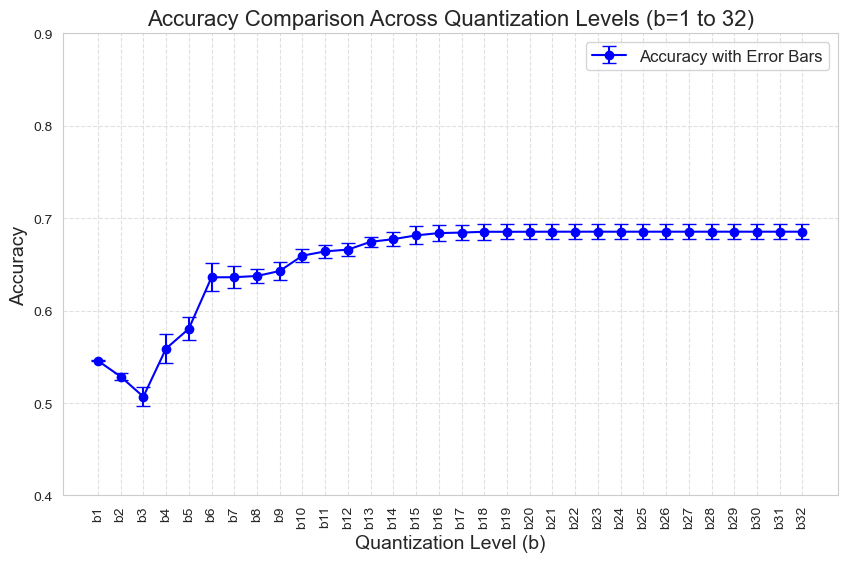

In [3]:
# classification
import pandas as pd
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

def quantize(data, b):
    min_val = data.min()
    max_val = data.max()

    levels = 2 ** b
    step = (max_val - min_val) / levels

    quantized_indexes = np.floor((data - min_val) / step)
    quantized_indexes = np.clip(quantized_indexes, 0, levels - 1)

    quantized_data = quantized_indexes * step + min_val
    return quantized_data, quantized_indexes

base_dir = "D:/ZBIOT-2025/Dataset"
input_folder = os.path.join(base_dir, "Merged_Data", "A_6-Merged_sequence_data_fix_durations")
output_folder = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_durations", "Quantized_values")
output_folder2 = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_durations", "Quantized_index")
os.makedirs(output_folder, exist_ok=True)
os.makedirs(output_folder2, exist_ok=True)

b_values = list(range(1, 33))  # b be from 1 to 32.

file_name = "Topology_B_fix_duration.csv"
input_file_path = os.path.join(input_folder, file_name)
df = pd.read_csv(input_file_path)
columns_to_quantize = df.columns[3:10]

for b in b_values:
    try:
        quantized_df = df.copy()
        index_df = df.copy()
        for col in columns_to_quantize:
            quantized_values, quantized_indexes = quantize(df[col].values, b)
            quantized_df[col] = quantized_values
            index_df[col] = quantized_indexes

        new_file_name = file_name.replace(".csv", "")
        output_file = os.path.join(output_folder, f"{new_file_name}_value_b{b}.csv")
        output_index_file = os.path.join(output_folder2, f"{new_file_name}_index_b{b}.csv")

        quantized_df.to_csv(output_file, index=False)
        index_df.to_csv(output_index_file, index=False)
    except MemoryError:
        print(f"Quantization failed for b={b}")

file_paths = {f"b{b}": os.path.join(output_folder, f"{new_file_name}_value_b{b}.csv") for b in b_values}
file_paths["Original"] = os.path.join(input_folder, file_name)

folds = 5
accuracies_per_file = {file_name: [] for file_name in file_paths.keys() if file_name != "Original"}

original_data = pd.read_csv(file_paths["Original"])
X_original = original_data.drop(columns=["Device Name", "Device Type", "File Name"])
y_original = original_data["Device Type"]
y_original = y_original.astype("category")
categories = y_original.cat.categories
y_original = y_original.cat.codes

skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)

for train_indices, test_indices in skf.split(X_original, y_original):
    X_train, X_test = X_original.iloc[train_indices], X_original.iloc[test_indices]
    y_train, y_test_original = y_original[train_indices], y_original[test_indices]

    class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

    rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
    rf_model.fit(X_train, y_train)

    for file_name, file_path in file_paths.items():
        if file_name == "Original":
            continue

        quantized_data = pd.read_csv(file_path)
        X_test_quantized = quantized_data.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[test_indices]
        y_test_quantized = quantized_data["Device Type"].iloc[test_indices]
        y_test_quantized = y_test_quantized.astype("category")
        y_test_quantized = y_test_quantized.cat.set_categories(categories).cat.codes

        y_pred = rf_model.predict(X_test_quantized)
        acc = accuracy_score(y_test_quantized, y_pred)
        accuracies_per_file[file_name].append(acc)

mean_accuracies = {file_name: np.mean(accs) for file_name, accs in accuracies_per_file.items()}
std_accuracies = {file_name: np.std(accs) for file_name, accs in accuracies_per_file.items()}

print("\n=== Final Results ===")
for file_name, mean_acc in sorted(mean_accuracies.items(), key=lambda x: int(x[0][1:])):
    print(f"{file_name}: Mean Accuracy = {mean_acc:.4f}, Std = {std_accuracies[file_name]:.4f}")

plt.figure(figsize=(10, 6))
b_values_sorted = sorted(mean_accuracies.keys(), key=lambda x: int(x[1:]))
plt.errorbar(
    b_values_sorted,
    [mean_accuracies[b] for b in b_values_sorted],
    yerr=[std_accuracies[b] for b in b_values_sorted],
    fmt="o-", capsize=5, label="Accuracy with Error Bars", color="blue",
)
plt.title("Accuracy Comparison Across Quantization Levels (b=1 to 32)", fontsize=16)
plt.xlabel("Quantization Level (b)", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.ylim(0.4, 0.9)
plt.xticks(rotation=90)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12)
plt.show()



=== Final Results ===
b1: Mean Accuracy = 0.1468, Std = 0.0142
b2: Mean Accuracy = 0.1551, Std = 0.0069
b3: Mean Accuracy = 0.1679, Std = 0.0061
b4: Mean Accuracy = 0.1796, Std = 0.0059
b5: Mean Accuracy = 0.1851, Std = 0.0104
b6: Mean Accuracy = 0.2377, Std = 0.0066
b7: Mean Accuracy = 0.2511, Std = 0.0064
b8: Mean Accuracy = 0.2605, Std = 0.0044
b9: Mean Accuracy = 0.2653, Std = 0.0084
b10: Mean Accuracy = 0.2956, Std = 0.0062
b11: Mean Accuracy = 0.3027, Std = 0.0080
b12: Mean Accuracy = 0.3076, Std = 0.0081
b13: Mean Accuracy = 0.3196, Std = 0.0082
b14: Mean Accuracy = 0.3237, Std = 0.0076
b15: Mean Accuracy = 0.3245, Std = 0.0064
b16: Mean Accuracy = 0.3288, Std = 0.0058
b17: Mean Accuracy = 0.3305, Std = 0.0045
b18: Mean Accuracy = 0.3330, Std = 0.0042
b19: Mean Accuracy = 0.3339, Std = 0.0047
b20: Mean Accuracy = 0.3336, Std = 0.0045
b21: Mean Accuracy = 0.3340, Std = 0.0042
b22: Mean Accuracy = 0.3342, Std = 0.0040
b23: Mean Accuracy = 0.3338, Std = 0.0037
b24: Mean Accuracy =

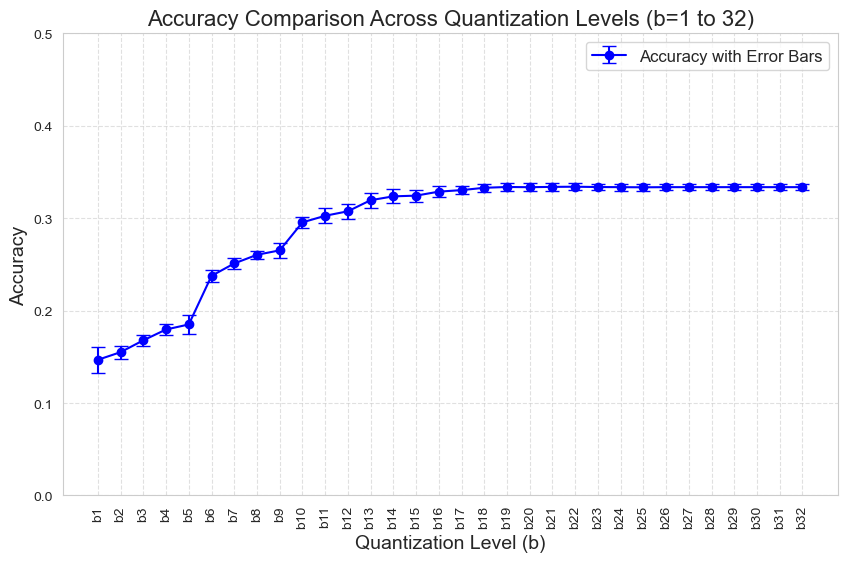

In [6]:
# identification
import pandas as pd
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

def quantize(data, b):
    min_val = data.min()
    max_val = data.max()

    levels = 2 ** b
    step = (max_val - min_val) / levels

    quantized_indexes = np.floor((data - min_val) / step)
    quantized_indexes = np.clip(quantized_indexes, 0, levels - 1)

    quantized_data = quantized_indexes * step + min_val
    return quantized_data, quantized_indexes

base_dir = "D:/ZBIOT-2025/Dataset"
input_folder = os.path.join(base_dir, "Merged_Data", "A_6-Merged_sequence_data_fix_durations")
output_folder = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_durations", "Quantized_values")
output_folder2 = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_durations", "Quantized_index")
os.makedirs(output_folder, exist_ok=True)
os.makedirs(output_folder2, exist_ok=True)

b_values = list(range(1, 33))  # b be from 1 to 32.

file_name = "Topology_B_fix_duration.csv"
input_file_path = os.path.join(input_folder, file_name)
df = pd.read_csv(input_file_path)
columns_to_quantize = df.columns[3:10]

for b in b_values:
    try:
        quantized_df = df.copy()
        index_df = df.copy()
        for col in columns_to_quantize:
            quantized_values, quantized_indexes = quantize(df[col].values, b)
            quantized_df[col] = quantized_values
            index_df[col] = quantized_indexes

        new_file_name = file_name.replace(".csv", "")
        output_file = os.path.join(output_folder, f"{new_file_name}_value_b{b}.csv")
        output_index_file = os.path.join(output_folder2, f"{new_file_name}_index_b{b}.csv")

        quantized_df.to_csv(output_file, index=False)
        index_df.to_csv(output_index_file, index=False)
    except MemoryError:
        print(f"Quantization failed for b={b}")

file_paths = {f"b{b}": os.path.join(output_folder, f"{new_file_name}_value_b{b}.csv") for b in b_values}
file_paths["Original"] = os.path.join(input_folder, file_name)

folds = 5
accuracies_per_file = {file_name: [] for file_name in file_paths.keys() if file_name != "Original"}

original_data = pd.read_csv(file_paths["Original"])
X_original = original_data.drop(columns=["Device Name", "Device Type", "File Name"])
y_original = original_data["Device Name"]
y_original = y_original.astype("category")
categories = y_original.cat.categories
y_original = y_original.cat.codes

skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)

for train_indices, test_indices in skf.split(X_original, y_original):
    X_train, X_test = X_original.iloc[train_indices], X_original.iloc[test_indices]
    y_train, y_test_original = y_original[train_indices], y_original[test_indices]

    class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

    rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
    rf_model.fit(X_train, y_train)

    for file_name, file_path in file_paths.items():
        if file_name == "Original":
            continue

        quantized_data = pd.read_csv(file_path)
        X_test_quantized = quantized_data.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[test_indices]
        y_test_quantized = quantized_data["Device Name"].iloc[test_indices]
        y_test_quantized = y_test_quantized.astype("category")
        y_test_quantized = y_test_quantized.cat.set_categories(categories).cat.codes

        y_pred = rf_model.predict(X_test_quantized)
        acc = accuracy_score(y_test_quantized, y_pred)
        accuracies_per_file[file_name].append(acc)

mean_accuracies = {file_name: np.mean(accs) for file_name, accs in accuracies_per_file.items()}
std_accuracies = {file_name: np.std(accs) for file_name, accs in accuracies_per_file.items()}

print("\n=== Final Results ===")
for file_name, mean_acc in sorted(mean_accuracies.items(), key=lambda x: int(x[0][1:])):
    print(f"{file_name}: Mean Accuracy = {mean_acc:.4f}, Std = {std_accuracies[file_name]:.4f}")

plt.figure(figsize=(10, 6))
b_values_sorted = sorted(mean_accuracies.keys(), key=lambda x: int(x[1:]))
plt.errorbar(
    b_values_sorted,
    [mean_accuracies[b] for b in b_values_sorted],
    yerr=[std_accuracies[b] for b in b_values_sorted],
    fmt="o-", capsize=5, label="Accuracy with Error Bars", color="blue",
)
plt.title("Accuracy Comparison Across Quantization Levels (b=1 to 32)", fontsize=16)
plt.xlabel("Quantization Level (b)", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.ylim(0, 0.5)
plt.xticks(rotation=90)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12)
plt.show()


## Topology_A packets


=== Final Results ===
b1: Mean Accuracy = 0.5549, Std = 0.0019
b2: Mean Accuracy = 0.5553, Std = 0.0012
b3: Mean Accuracy = 0.5564, Std = 0.0056
b4: Mean Accuracy = 0.6276, Std = 0.0112
b5: Mean Accuracy = 0.6458, Std = 0.0060
b6: Mean Accuracy = 0.6807, Std = 0.0075
b7: Mean Accuracy = 0.7253, Std = 0.0063
b8: Mean Accuracy = 0.7676, Std = 0.0058
b9: Mean Accuracy = 0.7963, Std = 0.0069
b10: Mean Accuracy = 0.8228, Std = 0.0070
b11: Mean Accuracy = 0.8506, Std = 0.0057
b12: Mean Accuracy = 0.8812, Std = 0.0034
b13: Mean Accuracy = 0.8904, Std = 0.0044
b14: Mean Accuracy = 0.8966, Std = 0.0033
b15: Mean Accuracy = 0.9007, Std = 0.0030
b16: Mean Accuracy = 0.9019, Std = 0.0031
b17: Mean Accuracy = 0.9024, Std = 0.0033
b18: Mean Accuracy = 0.9021, Std = 0.0033
b19: Mean Accuracy = 0.9021, Std = 0.0029
b20: Mean Accuracy = 0.9020, Std = 0.0030
b21: Mean Accuracy = 0.9020, Std = 0.0030
b22: Mean Accuracy = 0.9021, Std = 0.0031
b23: Mean Accuracy = 0.9021, Std = 0.0030
b24: Mean Accuracy =

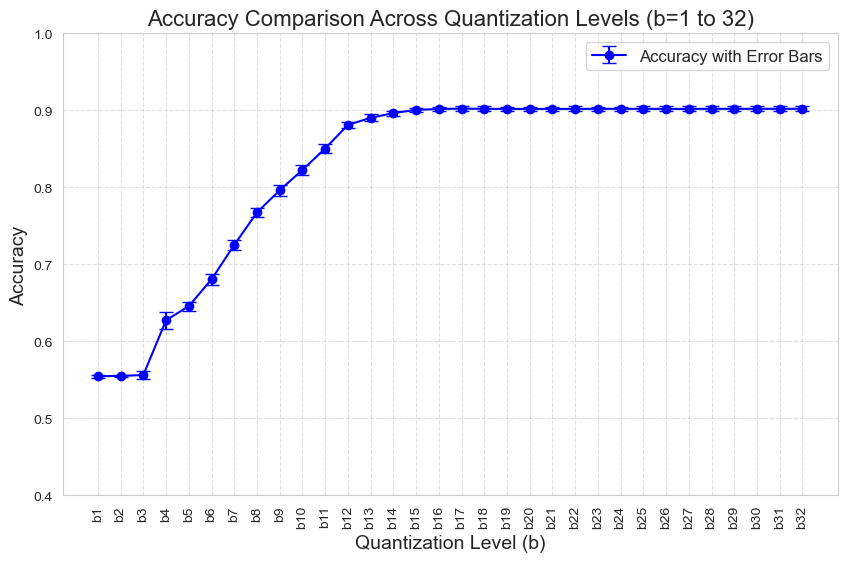

In [7]:
# classification
import pandas as pd
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

def quantize(data, b):
    min_val = data.min()
    max_val = data.max()

    levels = 2 ** b
    step = (max_val - min_val) / levels

    quantized_indexes = np.floor((data - min_val) / step)
    quantized_indexes = np.clip(quantized_indexes, 0, levels - 1)

    quantized_data = quantized_indexes * step + min_val
    return quantized_data, quantized_indexes

base_dir = "D:/ZBIOT-2025/Dataset"
input_folder = os.path.join(base_dir, "Merged_Data", "A_6-Merged_sequence_data_fix_packets")
output_folder = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_packets", "Quantized_values")
output_folder2 = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_packets", "Quantized_index")
os.makedirs(output_folder, exist_ok=True)
os.makedirs(output_folder2, exist_ok=True)

b_values = list(range(1, 33))  # b be from 1 to 32.

file_name = "Topology_A_fix_packets.csv"
input_file_path = os.path.join(input_folder, file_name)
df = pd.read_csv(input_file_path)
columns_to_quantize = df.columns[3:10]

for b in b_values:
    try:
        quantized_df = df.copy()
        index_df = df.copy()
        for col in columns_to_quantize:
            quantized_values, quantized_indexes = quantize(df[col].values, b)
            quantized_df[col] = quantized_values
            index_df[col] = quantized_indexes

        new_file_name = file_name.replace(".csv", "")
        output_file = os.path.join(output_folder, f"{new_file_name}_value_b{b}.csv")
        output_index_file = os.path.join(output_folder2, f"{new_file_name}_index_b{b}.csv")

        quantized_df.to_csv(output_file, index=False)
        index_df.to_csv(output_index_file, index=False)
    except MemoryError:
        print(f"Quantization failed for b={b}")

file_paths = {f"b{b}": os.path.join(output_folder, f"{new_file_name}_value_b{b}.csv") for b in b_values}
file_paths["Original"] = os.path.join(input_folder, file_name)

folds = 5
accuracies_per_file = {file_name: [] for file_name in file_paths.keys() if file_name != "Original"}

original_data = pd.read_csv(file_paths["Original"])
X_original = original_data.drop(columns=["Device Name", "Device Type", "File Name"])
y_original = original_data["Device Type"]
y_original = y_original.astype("category")
categories = y_original.cat.categories
y_original = y_original.cat.codes

skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)

for train_indices, test_indices in skf.split(X_original, y_original):
    X_train, X_test = X_original.iloc[train_indices], X_original.iloc[test_indices]
    y_train, y_test_original = y_original[train_indices], y_original[test_indices]

    class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

    rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
    rf_model.fit(X_train, y_train)

    for file_name, file_path in file_paths.items():
        if file_name == "Original":
            continue

        quantized_data = pd.read_csv(file_path)
        X_test_quantized = quantized_data.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[test_indices]
        y_test_quantized = quantized_data["Device Type"].iloc[test_indices]
        y_test_quantized = y_test_quantized.astype("category")
        y_test_quantized = y_test_quantized.cat.set_categories(categories).cat.codes

        y_pred = rf_model.predict(X_test_quantized)
        acc = accuracy_score(y_test_quantized, y_pred)
        accuracies_per_file[file_name].append(acc)

mean_accuracies = {file_name: np.mean(accs) for file_name, accs in accuracies_per_file.items()}
std_accuracies = {file_name: np.std(accs) for file_name, accs in accuracies_per_file.items()}

print("\n=== Final Results ===")
for file_name, mean_acc in sorted(mean_accuracies.items(), key=lambda x: int(x[0][1:])):
    print(f"{file_name}: Mean Accuracy = {mean_acc:.4f}, Std = {std_accuracies[file_name]:.4f}")

plt.figure(figsize=(10, 6))
b_values_sorted = sorted(mean_accuracies.keys(), key=lambda x: int(x[1:]))
plt.errorbar(
    b_values_sorted,
    [mean_accuracies[b] for b in b_values_sorted],
    yerr=[std_accuracies[b] for b in b_values_sorted],
    fmt="o-", capsize=5, label="Accuracy with Error Bars", color="blue",
)
plt.title("Accuracy Comparison Across Quantization Levels (b=1 to 32)", fontsize=16)
plt.xlabel("Quantization Level (b)", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.ylim(0.4, 1)
plt.xticks(rotation=90)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12)
plt.show()


D:\Anaconda\envs\compression\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(



=== Final Results ===
b1: Mean Accuracy = 0.1424, Std = 0.0139
b2: Mean Accuracy = 0.1779, Std = 0.0038
b3: Mean Accuracy = 0.1839, Std = 0.0057
b4: Mean Accuracy = 0.2273, Std = 0.0051
b5: Mean Accuracy = 0.2720, Std = 0.0065
b6: Mean Accuracy = 0.3589, Std = 0.0045
b7: Mean Accuracy = 0.4385, Std = 0.0039
b8: Mean Accuracy = 0.5115, Std = 0.0062
b9: Mean Accuracy = 0.5781, Std = 0.0040
b10: Mean Accuracy = 0.6204, Std = 0.0054
b11: Mean Accuracy = 0.6652, Std = 0.0048
b12: Mean Accuracy = 0.7134, Std = 0.0043
b13: Mean Accuracy = 0.7250, Std = 0.0043
b14: Mean Accuracy = 0.7457, Std = 0.0038
b15: Mean Accuracy = 0.7616, Std = 0.0032
b16: Mean Accuracy = 0.7650, Std = 0.0039
b17: Mean Accuracy = 0.7679, Std = 0.0042
b18: Mean Accuracy = 0.7683, Std = 0.0044
b19: Mean Accuracy = 0.7687, Std = 0.0038
b20: Mean Accuracy = 0.7692, Std = 0.0035
b21: Mean Accuracy = 0.7696, Std = 0.0041
b22: Mean Accuracy = 0.7695, Std = 0.0042
b23: Mean Accuracy = 0.7695, Std = 0.0041
b24: Mean Accuracy =

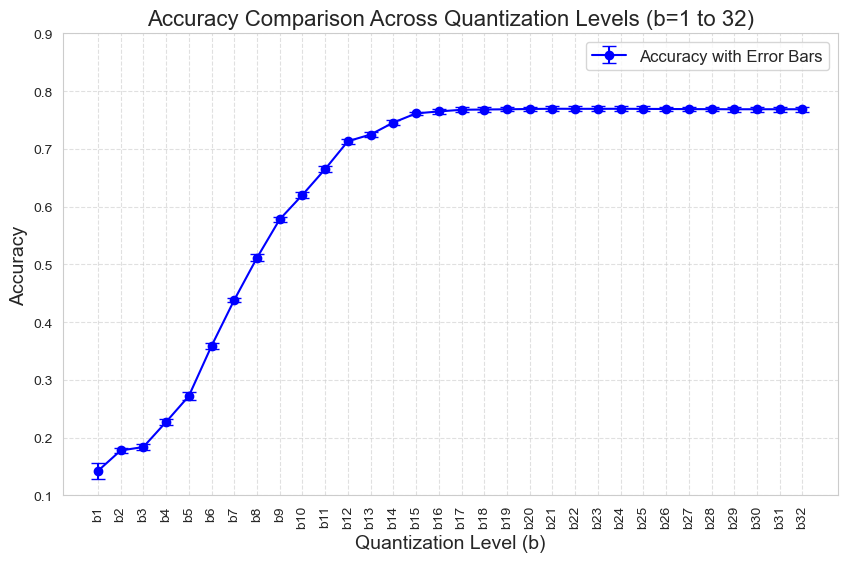

In [9]:
# identification
import pandas as pd
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

def quantize(data, b):
    min_val = data.min()
    max_val = data.max()

    levels = 2 ** b
    step = (max_val - min_val) / levels

    quantized_indexes = np.floor((data - min_val) / step)
    quantized_indexes = np.clip(quantized_indexes, 0, levels - 1)

    quantized_data = quantized_indexes * step + min_val
    return quantized_data, quantized_indexes

base_dir = "D:/ZBIOT-2025/Dataset"
input_folder = os.path.join(base_dir, "Merged_Data", "A_6-Merged_sequence_data_fix_packets")
output_folder = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_packets", "Quantized_values")
output_folder2 = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_packets", "Quantized_index")
os.makedirs(output_folder, exist_ok=True)
os.makedirs(output_folder2, exist_ok=True)

b_values = list(range(1, 33))  # b be from 1 to 32.

file_name = "Topology_A_fix_packets.csv"
input_file_path = os.path.join(input_folder, file_name)
df = pd.read_csv(input_file_path)
columns_to_quantize = df.columns[3:10]

for b in b_values:
    try:
        quantized_df = df.copy()
        index_df = df.copy()
        for col in columns_to_quantize:
            quantized_values, quantized_indexes = quantize(df[col].values, b)
            quantized_df[col] = quantized_values
            index_df[col] = quantized_indexes

        new_file_name = file_name.replace(".csv", "")
        output_file = os.path.join(output_folder, f"{new_file_name}_value_b{b}.csv")
        output_index_file = os.path.join(output_folder2, f"{new_file_name}_index_b{b}.csv")

        quantized_df.to_csv(output_file, index=False)
        index_df.to_csv(output_index_file, index=False)
    except MemoryError:
        print(f"Quantization failed for b={b}")

file_paths = {f"b{b}": os.path.join(output_folder, f"{new_file_name}_value_b{b}.csv") for b in b_values}
file_paths["Original"] = os.path.join(input_folder, file_name)

folds = 5
accuracies_per_file = {file_name: [] for file_name in file_paths.keys() if file_name != "Original"}

original_data = pd.read_csv(file_paths["Original"])
X_original = original_data.drop(columns=["Device Name", "Device Type", "File Name"])
y_original = original_data["Device Name"]
y_original = y_original.astype("category")
categories = y_original.cat.categories
y_original = y_original.cat.codes

skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)

for train_indices, test_indices in skf.split(X_original, y_original):
    X_train, X_test = X_original.iloc[train_indices], X_original.iloc[test_indices]
    y_train, y_test_original = y_original[train_indices], y_original[test_indices]

    class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

    rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
    rf_model.fit(X_train, y_train)

    for file_name, file_path in file_paths.items():
        if file_name == "Original":
            continue

        quantized_data = pd.read_csv(file_path)
        X_test_quantized = quantized_data.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[test_indices]
        y_test_quantized = quantized_data["Device Name"].iloc[test_indices]
        y_test_quantized = y_test_quantized.astype("category")
        y_test_quantized = y_test_quantized.cat.set_categories(categories).cat.codes

        y_pred = rf_model.predict(X_test_quantized)
        acc = accuracy_score(y_test_quantized, y_pred)
        accuracies_per_file[file_name].append(acc)

mean_accuracies = {file_name: np.mean(accs) for file_name, accs in accuracies_per_file.items()}
std_accuracies = {file_name: np.std(accs) for file_name, accs in accuracies_per_file.items()}

print("\n=== Final Results ===")
for file_name, mean_acc in sorted(mean_accuracies.items(), key=lambda x: int(x[0][1:])):
    print(f"{file_name}: Mean Accuracy = {mean_acc:.4f}, Std = {std_accuracies[file_name]:.4f}")

plt.figure(figsize=(10, 6))
b_values_sorted = sorted(mean_accuracies.keys(), key=lambda x: int(x[1:]))
plt.errorbar(
    b_values_sorted,
    [mean_accuracies[b] for b in b_values_sorted],
    yerr=[std_accuracies[b] for b in b_values_sorted],
    fmt="o-", capsize=5, label="Accuracy with Error Bars", color="blue",
)
plt.title("Accuracy Comparison Across Quantization Levels (b=1 to 32)", fontsize=16)
plt.xlabel("Quantization Level (b)", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.ylim(0.1, 0.9)
plt.xticks(rotation=90)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12)
plt.show()


## Topology_B packets


=== Final Results ===
b1: Mean Accuracy = 0.4885, Std = 0.0661
b2: Mean Accuracy = 0.5481, Std = 0.0231
b3: Mean Accuracy = 0.7072, Std = 0.0060
b4: Mean Accuracy = 0.7358, Std = 0.0085
b5: Mean Accuracy = 0.7390, Std = 0.0083
b6: Mean Accuracy = 0.7516, Std = 0.0062
b7: Mean Accuracy = 0.7747, Std = 0.0044
b8: Mean Accuracy = 0.8128, Std = 0.0051
b9: Mean Accuracy = 0.8397, Std = 0.0040
b10: Mean Accuracy = 0.8766, Std = 0.0029
b11: Mean Accuracy = 0.8846, Std = 0.0048
b12: Mean Accuracy = 0.8903, Std = 0.0040
b13: Mean Accuracy = 0.9031, Std = 0.0034
b14: Mean Accuracy = 0.9086, Std = 0.0035
b15: Mean Accuracy = 0.9124, Std = 0.0036
b16: Mean Accuracy = 0.9146, Std = 0.0032
b17: Mean Accuracy = 0.9156, Std = 0.0032
b18: Mean Accuracy = 0.9157, Std = 0.0033
b19: Mean Accuracy = 0.9157, Std = 0.0033
b20: Mean Accuracy = 0.9158, Std = 0.0033
b21: Mean Accuracy = 0.9159, Std = 0.0034
b22: Mean Accuracy = 0.9160, Std = 0.0034
b23: Mean Accuracy = 0.9161, Std = 0.0034
b24: Mean Accuracy =

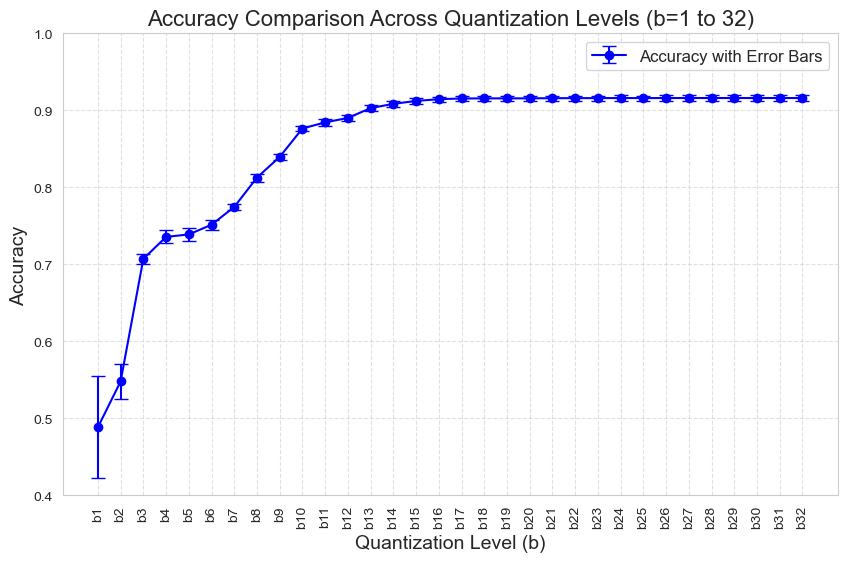

In [10]:
import pandas as pd
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

def quantize(data, b):
    min_val = data.min()
    max_val = data.max()

    levels = 2 ** b
    step = (max_val - min_val) / levels

    quantized_indexes = np.floor((data - min_val) / step)
    quantized_indexes = np.clip(quantized_indexes, 0, levels - 1)

    quantized_data = quantized_indexes * step + min_val
    return quantized_data, quantized_indexes

base_dir = "D:/ZBIOT-2025/Dataset"
input_folder = os.path.join(base_dir, "Merged_Data", "A_6-Merged_sequence_data_fix_packets")
output_folder = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_packets", "Quantized_values")
output_folder2 = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_packets", "Quantized_index")
os.makedirs(output_folder, exist_ok=True)
os.makedirs(output_folder2, exist_ok=True)

b_values = list(range(1, 33))  # b be from 1 to 32.

file_name = "Topology_B_fix_packets.csv"
input_file_path = os.path.join(input_folder, file_name)
df = pd.read_csv(input_file_path)
columns_to_quantize = df.columns[3:10]

for b in b_values:
    try:
        quantized_df = df.copy()
        index_df = df.copy()
        for col in columns_to_quantize:
            quantized_values, quantized_indexes = quantize(df[col].values, b)
            quantized_df[col] = quantized_values
            index_df[col] = quantized_indexes

        new_file_name = file_name.replace(".csv", "")
        output_file = os.path.join(output_folder, f"{new_file_name}_value_b{b}.csv")
        output_index_file = os.path.join(output_folder2, f"{new_file_name}_index_b{b}.csv")

        quantized_df.to_csv(output_file, index=False)
        index_df.to_csv(output_index_file, index=False)
    except MemoryError:
        print(f"Quantization failed for b={b}")

file_paths = {f"b{b}": os.path.join(output_folder, f"{new_file_name}_value_b{b}.csv") for b in b_values}
file_paths["Original"] = os.path.join(input_folder, file_name)

folds = 5
accuracies_per_file = {file_name: [] for file_name in file_paths.keys() if file_name != "Original"}

original_data = pd.read_csv(file_paths["Original"])
X_original = original_data.drop(columns=["Device Name", "Device Type", "File Name"])
y_original = original_data["Device Type"]
y_original = y_original.astype("category")
categories = y_original.cat.categories
y_original = y_original.cat.codes

skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)

for train_indices, test_indices in skf.split(X_original, y_original):
    X_train, X_test = X_original.iloc[train_indices], X_original.iloc[test_indices]
    y_train, y_test_original = y_original[train_indices], y_original[test_indices]

    class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

    rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
    rf_model.fit(X_train, y_train)

    for file_name, file_path in file_paths.items():
        if file_name == "Original":
            continue

        quantized_data = pd.read_csv(file_path)
        X_test_quantized = quantized_data.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[test_indices]
        y_test_quantized = quantized_data["Device Type"].iloc[test_indices]
        y_test_quantized = y_test_quantized.astype("category")
        y_test_quantized = y_test_quantized.cat.set_categories(categories).cat.codes

        y_pred = rf_model.predict(X_test_quantized)
        acc = accuracy_score(y_test_quantized, y_pred)
        accuracies_per_file[file_name].append(acc)

mean_accuracies = {file_name: np.mean(accs) for file_name, accs in accuracies_per_file.items()}
std_accuracies = {file_name: np.std(accs) for file_name, accs in accuracies_per_file.items()}

print("\n=== Final Results ===")
for file_name, mean_acc in sorted(mean_accuracies.items(), key=lambda x: int(x[0][1:])):
    print(f"{file_name}: Mean Accuracy = {mean_acc:.4f}, Std = {std_accuracies[file_name]:.4f}")

plt.figure(figsize=(10, 6))
b_values_sorted = sorted(mean_accuracies.keys(), key=lambda x: int(x[1:]))
plt.errorbar(
    b_values_sorted,
    [mean_accuracies[b] for b in b_values_sorted],
    yerr=[std_accuracies[b] for b in b_values_sorted],
    fmt="o-", capsize=5, label="Accuracy with Error Bars", color="blue",
)
plt.title("Accuracy Comparison Across Quantization Levels (b=1 to 32)", fontsize=16)
plt.xlabel("Quantization Level (b)", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.ylim(0.4, 1)
plt.xticks(rotation=90)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12)
plt.show()



=== Final Results ===
b1: Mean Accuracy = 0.1237, Std = 0.0135
b2: Mean Accuracy = 0.1539, Std = 0.0042
b3: Mean Accuracy = 0.2218, Std = 0.0074
b4: Mean Accuracy = 0.2713, Std = 0.0023
b5: Mean Accuracy = 0.3090, Std = 0.0030
b6: Mean Accuracy = 0.3429, Std = 0.0045
b7: Mean Accuracy = 0.4014, Std = 0.0084
b8: Mean Accuracy = 0.4930, Std = 0.0082
b9: Mean Accuracy = 0.5678, Std = 0.0065
b10: Mean Accuracy = 0.6367, Std = 0.0048
b11: Mean Accuracy = 0.6613, Std = 0.0028
b12: Mean Accuracy = 0.6777, Std = 0.0022
b13: Mean Accuracy = 0.7143, Std = 0.0040
b14: Mean Accuracy = 0.7273, Std = 0.0020
b15: Mean Accuracy = 0.7338, Std = 0.0027
b16: Mean Accuracy = 0.7402, Std = 0.0028
b17: Mean Accuracy = 0.7436, Std = 0.0023
b18: Mean Accuracy = 0.7456, Std = 0.0026
b19: Mean Accuracy = 0.7466, Std = 0.0030
b20: Mean Accuracy = 0.7465, Std = 0.0030
b21: Mean Accuracy = 0.7466, Std = 0.0029
b22: Mean Accuracy = 0.7466, Std = 0.0025
b23: Mean Accuracy = 0.7466, Std = 0.0025
b24: Mean Accuracy =

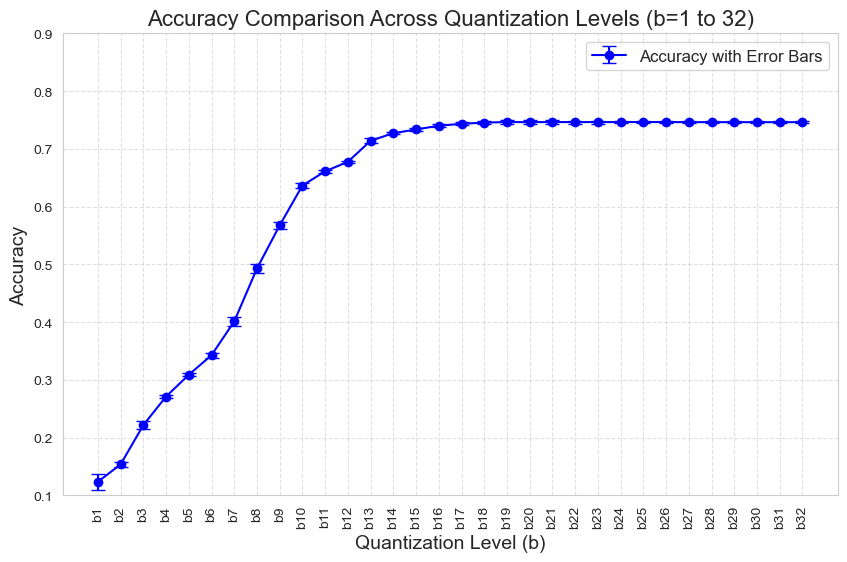

In [11]:
import pandas as pd
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

def quantize(data, b):
    min_val = data.min()
    max_val = data.max()

    levels = 2 ** b
    step = (max_val - min_val) / levels

    quantized_indexes = np.floor((data - min_val) / step)
    quantized_indexes = np.clip(quantized_indexes, 0, levels - 1)

    quantized_data = quantized_indexes * step + min_val
    return quantized_data, quantized_indexes

base_dir = "D:/ZBIOT-2025/Dataset"
input_folder = os.path.join(base_dir, "Merged_Data", "A_6-Merged_sequence_data_fix_packets")
output_folder = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_packets", "Quantized_values")
output_folder2 = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_packets", "Quantized_index")
os.makedirs(output_folder, exist_ok=True)
os.makedirs(output_folder2, exist_ok=True)

b_values = list(range(1, 33))  # b be from 1 to 32.

file_name = "Topology_B_fix_packets.csv"
input_file_path = os.path.join(input_folder, file_name)
df = pd.read_csv(input_file_path)
columns_to_quantize = df.columns[3:10]

for b in b_values:
    try:
        quantized_df = df.copy()
        index_df = df.copy()
        for col in columns_to_quantize:
            quantized_values, quantized_indexes = quantize(df[col].values, b)
            quantized_df[col] = quantized_values
            index_df[col] = quantized_indexes

        new_file_name = file_name.replace(".csv", "")
        output_file = os.path.join(output_folder, f"{new_file_name}_value_b{b}.csv")
        output_index_file = os.path.join(output_folder2, f"{new_file_name}_index_b{b}.csv")

        quantized_df.to_csv(output_file, index=False)
        index_df.to_csv(output_index_file, index=False)
    except MemoryError:
        print(f"Quantization failed for b={b}")

file_paths = {f"b{b}": os.path.join(output_folder, f"{new_file_name}_value_b{b}.csv") for b in b_values}
file_paths["Original"] = os.path.join(input_folder, file_name)

folds = 5
accuracies_per_file = {file_name: [] for file_name in file_paths.keys() if file_name != "Original"}

original_data = pd.read_csv(file_paths["Original"])
X_original = original_data.drop(columns=["Device Name", "Device Type", "File Name"])
y_original = original_data["Device Name"]
y_original = y_original.astype("category")
categories = y_original.cat.categories
y_original = y_original.cat.codes

skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)

for train_indices, test_indices in skf.split(X_original, y_original):
    X_train, X_test = X_original.iloc[train_indices], X_original.iloc[test_indices]
    y_train, y_test_original = y_original[train_indices], y_original[test_indices]

    class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

    rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
    rf_model.fit(X_train, y_train)

    for file_name, file_path in file_paths.items():
        if file_name == "Original":
            continue

        quantized_data = pd.read_csv(file_path)
        X_test_quantized = quantized_data.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[test_indices]
        y_test_quantized = quantized_data["Device Name"].iloc[test_indices]
        y_test_quantized = y_test_quantized.astype("category")
        y_test_quantized = y_test_quantized.cat.set_categories(categories).cat.codes

        y_pred = rf_model.predict(X_test_quantized)
        acc = accuracy_score(y_test_quantized, y_pred)
        accuracies_per_file[file_name].append(acc)

mean_accuracies = {file_name: np.mean(accs) for file_name, accs in accuracies_per_file.items()}
std_accuracies = {file_name: np.std(accs) for file_name, accs in accuracies_per_file.items()}

print("\n=== Final Results ===")
for file_name, mean_acc in sorted(mean_accuracies.items(), key=lambda x: int(x[0][1:])):
    print(f"{file_name}: Mean Accuracy = {mean_acc:.4f}, Std = {std_accuracies[file_name]:.4f}")

plt.figure(figsize=(10, 6))
b_values_sorted = sorted(mean_accuracies.keys(), key=lambda x: int(x[1:]))
plt.errorbar(
    b_values_sorted,
    [mean_accuracies[b] for b in b_values_sorted],
    yerr=[std_accuracies[b] for b in b_values_sorted],
    fmt="o-", capsize=5, label="Accuracy with Error Bars", color="blue",
)
plt.title("Accuracy Comparison Across Quantization Levels (b=1 to 32)", fontsize=16)
plt.xlabel("Quantization Level (b)", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.ylim(0.1, 0.9)
plt.xticks(rotation=90)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12)
plt.show()
